In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Perceptron

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten, MaxPooling2D, Conv2D 
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential

In [32]:
df_train = pd.read_csv('mnist_train.csv')
df_test = pd.read_csv('mnist_test.csv')

In [3]:
df_train

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df_train.shape

(60000, 785)

In [5]:
df_train.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [7]:
X_train = df_train.drop(labels='label', axis=1).values
y_train = df_train['label'].values

X_test = df_test.drop(labels='label', axis=1).values
y_test = df_test['label'].values

In [8]:
# Convert Value between 0 - 255
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784), dtype=float32)

In [9]:
# Reshape to Matrix of Image 28 x 28
# Here reshape(layers, row, columns) with layers = -1 -> automatic
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [10]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [11]:
y_train_cat = to_categorical(y_train ,10)
y_test_cat = to_categorical(y_test, 10)

In [12]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])

In [13]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [14]:
history_percp = perceptron.fit(
    X_train_img, 
    y_train_cat, 
    epochs=5, 
    batch_size=32, 
    validation_data=(X_test_img, y_test_cat), 
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8163 - loss: 0.7765 - val_accuracy: 0.8820 - val_loss: 0.4833
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8802 - loss: 0.4570 - val_accuracy: 0.8934 - val_loss: 0.4020
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8906 - loss: 0.4038 - val_accuracy: 0.9020 - val_loss: 0.3686
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8965 - loss: 0.3773 - val_accuracy: 0.9064 - val_loss: 0.3498
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9007 - loss: 0.3605 - val_accuracy: 0.9102 - val_loss: 0.3368


In [15]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [16]:
acc_percp

0.9101999998092651

In [17]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [18]:
ann.compile(optimizer = 'adam', 
            loss='categorical_crossentropy', 
            metrics=['accuracy'])

In [19]:
history_ann = ann.fit(
    X_train_img, 
    y_train_cat, 
    epochs=5, 
    batch_size=32, 
    validation_data=(X_test_img, y_test_cat), 
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9297 - loss: 0.2361 - val_accuracy: 0.9536 - val_loss: 0.1554
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9695 - loss: 0.0997 - val_accuracy: 0.9684 - val_loss: 0.0992
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9786 - loss: 0.0681 - val_accuracy: 0.9699 - val_loss: 0.1021
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9833 - loss: 0.0527 - val_accuracy: 0.9763 - val_loss: 0.0819
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9863 - loss: 0.0424 - val_accuracy: 0.9737 - val_loss: 0.0899


In [52]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]

# reshape(layers, rows, columns, channel for image)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [23]:
cnn = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [24]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [27]:
history_cnn = cnn.fit(
    X_train_cnn, 
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9369 - loss: 0.2044 - val_accuracy: 0.9845 - val_loss: 0.0471
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9766 - loss: 0.0777 - val_accuracy: 0.9884 - val_loss: 0.0349
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9836 - loss: 0.0564 - val_accuracy: 0.9896 - val_loss: 0.0301
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9864 - loss: 0.0459 - val_accuracy: 0.9918 - val_loss: 0.0242
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9881 - loss: 0.0397 - val_accuracy: 0.9910 - val_loss: 0.0270


In [28]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
acc_cnn

0.9909999966621399

In [35]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

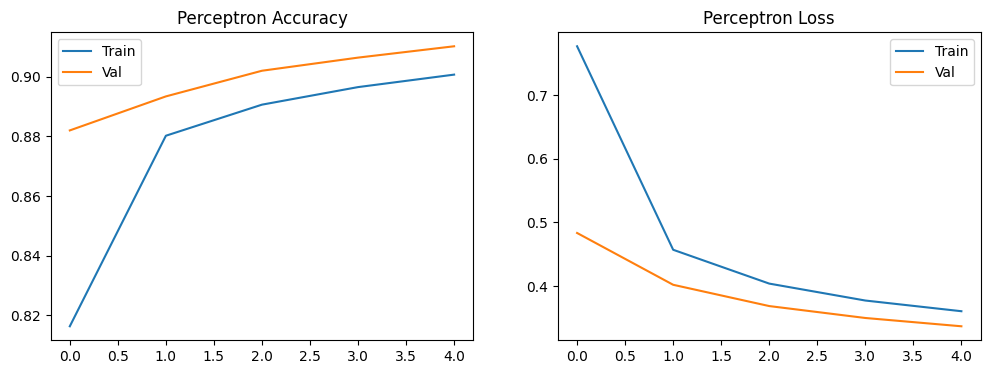

In [36]:
plot_training(history_percp, "Perceptron")

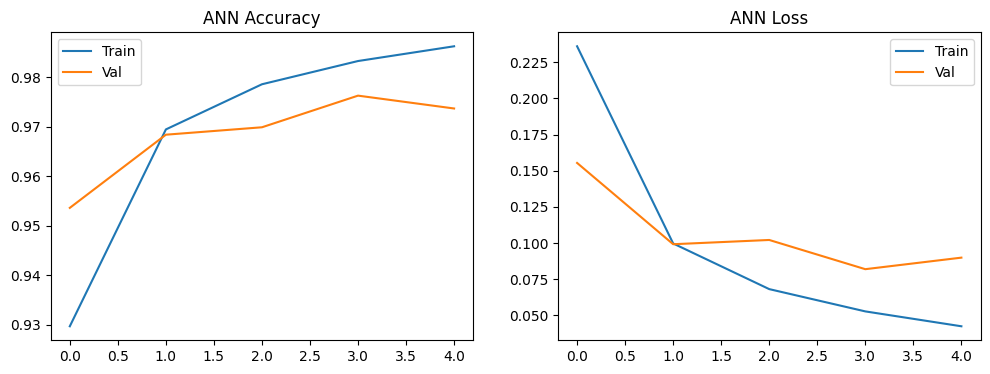

In [37]:
plot_training(history_ann, "ANN")

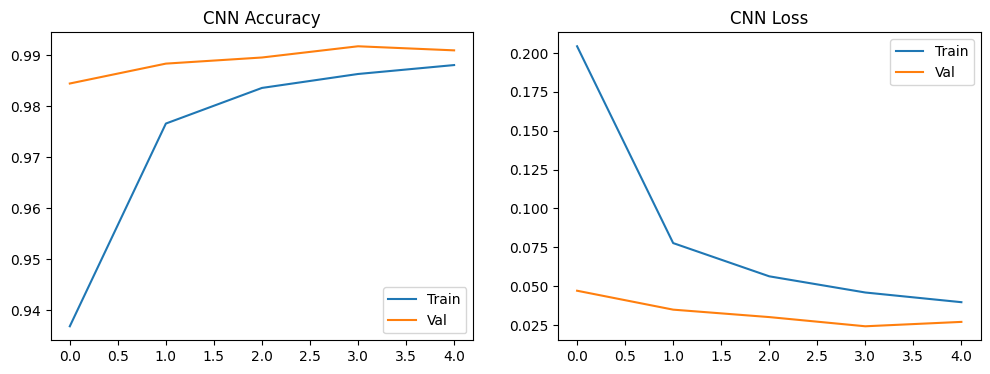

In [39]:
plot_training(history_cnn, "CNN")

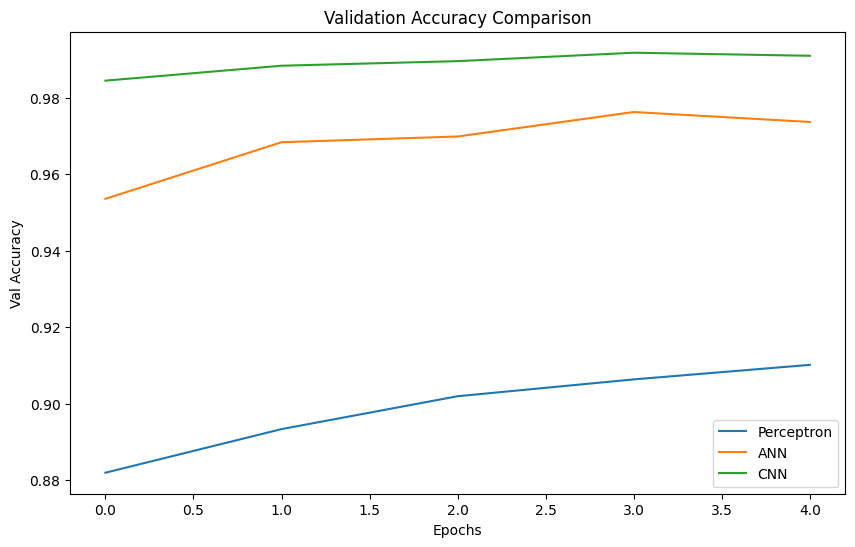

In [40]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [41]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)

    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(idxs):

        # Show image
        plt.subplot(2, n, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")

        # Predictions from all models
        preds = [
            np.argmax(
                model.predict(
                    X_cnn[idx].reshape(1, 28, 28, 1)
                    if name == "CNN"
                    else X[idx].reshape(1, 28, 28)
                )
            )
            for model, name in zip(models, model_names)
        ]

        # Display predictions
        plt.subplot(2, n, n + i + 1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


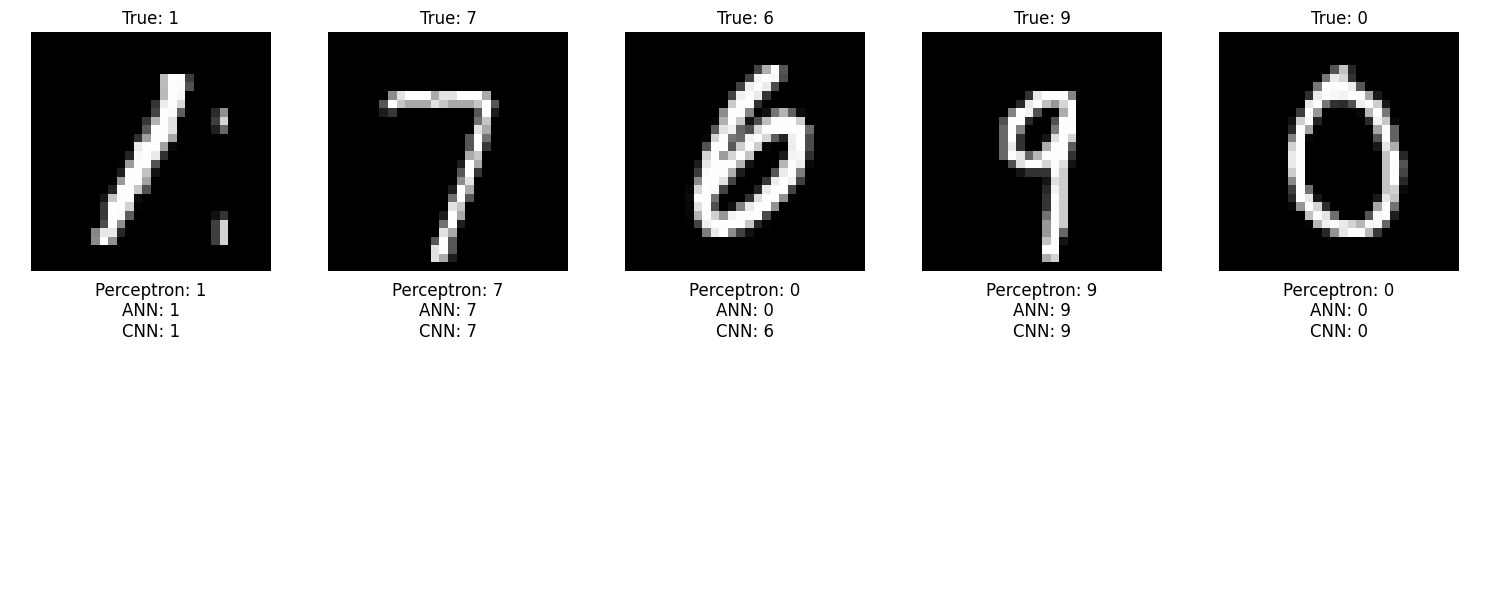

In [46]:
show_side_by_side(
    [perceptron, ann, cnn],
    ["Perceptron", "ANN", "CNN"],
    X_test_img,
    X_test_cnn,
    y_test,
    5
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


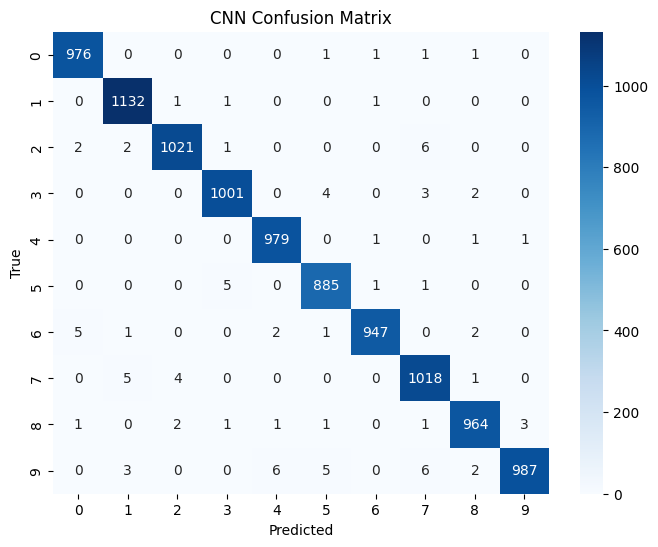

In [49]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)

cm = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

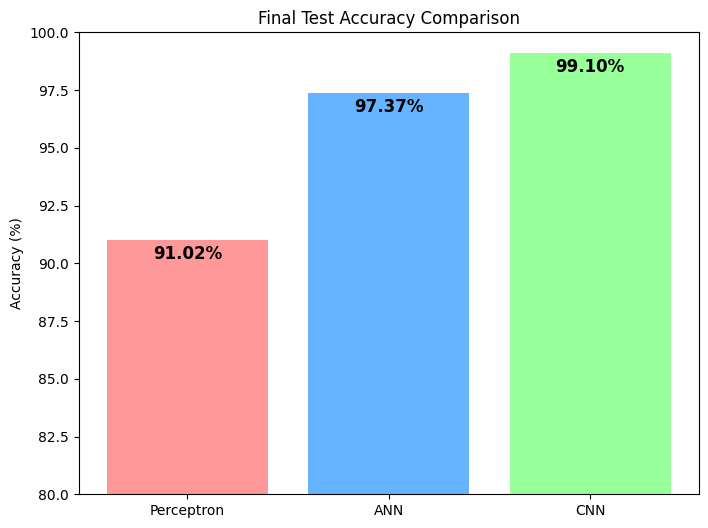

In [53]:
final_accs = [acc_percp * 100, acc_ann * 100, acc_cnn * 100]

models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    models,
    final_accs,
    color=['#ff9999', '#66b3ff', '#99ff99']
)

plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")

for bar, acc in zip(bars, final_accs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 1,
        f"{acc:.2f}%",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.ylim(80, 100)

plt.show()